# Llm deliberation scalar acceptance boundary

This notebook belongs to the project's sequential measurement and validation programme. Read its result as evidence about behavioural validity, representation, comparator strength, timing, information matching, or mechanistic calibration as appropriate. Legacy H1/H_priv identifiers may remain inside code, saved paths, or frozen schemas for reproducibility; they are not the object being "found" by the current analysis.

**Repository framing.** The current paper separates target-specific representation from predictive privilege. A positive neural result is interpreted only after behavioural validity, control, comparator-strength, timing, and information-set checks.


# Latent reservations — Notebook 07b
## LLM-Deliberation scalar acceptance-boundary repair

Notebook 07 established a useful parent-state activation design, but its candidate branch asked the model to reconstruct a five-issue private score and make an immediate one-token decision. That branch violated the benchmark's own hard minimum rule often enough that the revealed boundary was not valid.

This repair keeps the scientific structure fixed:

- same 30 immutable parent states;
- same five source-trajectory folds;
- same already-frozen legal candidate score grid;
- parent activation captured before any candidate value is revealed;
- one-token ACCEPT / REJECT consequence branch;
- same strong text, threshold, structured, and constant baselines.

The only substantive repair is the candidate interface.

For each candidate replay the experimenter provides the **already-verified private score directly**. The subject is explicitly told:

- do not recompute the five-issue score;
- the stated score is the complete payoff for this controlled branch;
- all other parties automatically approve if the subject ACCEPTs;
- no extra side bonus is added;
- REJECT returns to the same frozen negotiation state;
- a score below the benchmark's explicit minimum is not legally acceptable.

This removes issue-composition and arithmetic nuisance while preserving the state-conditioned continuation-value question.

Outputs are isolated under:

`/workspace/latent-reservations/notebook_outputs/07b_llm_deliberation_scalar_acceptance_boundary/<RUN_ID>/`


### v2 implementation repair

The first execution exposed an edge case: the overall global next-token validity rate can be high while one parent state still has zero legal `0`/`1` decisions, leaving that state's isotonic fit with an empty array.

v2:

- permits exactly one deterministic **format-only retry** when the initial global next token is not `0` or `1`;
- records the initial token, whether a retry was used, and the final token;
- requires at least one legal consequential decision for every parent state before boundary fitting;
- raises an explicit state-level diagnostic instead of passing an empty array to scikit-learn;
- never substitutes restricted `0`/`1` logits for the consequential action.


In [1]:
NOTEBOOK_BUILD = "latent-reservations-notebook07b-scalar-acceptance-boundary-v2"
print("=" * 88)
print(f"NOTEBOOK BUILD: {NOTEBOOK_BUILD}")
print("LLM-Deliberation scalar acceptance-boundary repair")
print("=" * 88)


NOTEBOOK BUILD: latent-reservations-notebook07b-scalar-acceptance-boundary-v2
LLM-Deliberation scalar acceptance-boundary repair


## 1. Dependencies


In [2]:
import importlib.util
import subprocess
import sys

packages = [
    "transformers>=4.45,<5",
    "accelerate>=0.30,<2",
    "safetensors>=0.4",
    "numpy<2",
    "pandas>=2,<3",
    "scipy>=1.12,<2",
    "scikit-learn>=1.4,<2",
    "matplotlib>=3.8,<4",
    "tqdm>=4.66",
]
subprocess.run([sys.executable, "-m", "pip", "install", *packages], check=True)
if importlib.util.find_spec("torch") is None:
    raise RuntimeError("PyTorch is required in the active environment.")
print("Notebook 07b dependencies ready.")


Notebook 07b dependencies ready.


## 2. Paths and isolated run directory


In [3]:
from __future__ import annotations

import hashlib
import json
import os
import re
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

PROJECT_ROOT = Path(
    os.environ.get("LR_PROJECT_ROOT", "/workspace/latent-reservations")
).expanduser().resolve()

NOTEBOOK_SLUG = "07b_llm_deliberation_scalar_acceptance_boundary"
RUN_ID = os.environ.get(
    "LR_RUN_ID",
    datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ"),
)

NOTEBOOK_OUTPUT_BASE = PROJECT_ROOT / "notebook_outputs" / NOTEBOOK_SLUG
RUN_OUTPUT_DIR = NOTEBOOK_OUTPUT_BASE / RUN_ID

MANIFEST_DIR = RUN_OUTPUT_DIR / "manifests"
DATA_DIR = RUN_OUTPUT_DIR / "data"
INPUT_DIR = RUN_OUTPUT_DIR / "inputs"
PARENT_STATE_DIR = INPUT_DIR / "parent_states"
CANDIDATE_BANK_DIR = INPUT_DIR / "candidate_banks"
PARENT_ACTIVATION_DIR = DATA_DIR / "parent_activations"
CHOICE_DIR = DATA_DIR / "branches" / "candidate_choices"
AUDITOR_DIR = DATA_DIR / "branches" / "auditor"
DERIVED_DIR = DATA_DIR / "derived"
TABLE_DIR = RUN_OUTPUT_DIR / "results" / "tables"
FIGURE_DIR = RUN_OUTPUT_DIR / "results" / "figures"

HF_CACHE_DIR = Path(
    os.environ.get("HF_HOME", "/workspace/.cache/huggingface")
).expanduser().resolve()

for p in [
    MANIFEST_DIR, PARENT_STATE_DIR, CANDIDATE_BANK_DIR,
    PARENT_ACTIVATION_DIR, CHOICE_DIR, AUDITOR_DIR,
    DERIVED_DIR, TABLE_DIR, FIGURE_DIR,
]:
    p.mkdir(parents=True, exist_ok=True)

NOTEBOOK_OUTPUT_BASE.mkdir(parents=True, exist_ok=True)
(NOTEBOOK_OUTPUT_BASE / "latest_run.json").write_text(json.dumps({
    "notebook_slug": NOTEBOOK_SLUG,
    "run_id": RUN_ID,
    "run_output_dir": str(RUN_OUTPUT_DIR),
    "updated_at_utc": datetime.now(timezone.utc).isoformat(),
}, indent=2))

print(f"RUN_OUTPUT_DIR = {RUN_OUTPUT_DIR}")


RUN_OUTPUT_DIR = /workspace/latent-reservations/notebook_outputs/07b_llm_deliberation_scalar_acceptance_boundary/20260814T103440Z


## 3. Snapshot Notebook 07's pre-outcome inputs

Only Notebook 07's immutable parent states, candidate banks, trajectory folds, subject checkpoint, and upstream commit are reused.

Notebook 07's candidate choices, revealed boundaries, activation predictions, and H1 labels are **not** reused.


In [4]:
NB07_BASE = PROJECT_ROOT / "notebook_outputs" / "07_llm_deliberation_acceptance_boundary"
nb07_latest_path = NB07_BASE / "latest_run.json"
if not nb07_latest_path.exists():
    raise FileNotFoundError(nb07_latest_path)

nb07_latest = json.loads(nb07_latest_path.read_text())
NB07_RUN_DIR = Path(nb07_latest["run_output_dir"])

nb07_summary_path = NB07_RUN_DIR / "results" / "tables" / "result_summary.json"
nb07_parent_dir = NB07_RUN_DIR / "data" / "parent_states"
nb07_bank_dir = NB07_RUN_DIR / "data" / "candidate_banks"
nb07_folds_path = NB07_RUN_DIR / "data" / "derived" / "trajectory_folds.json"

for p in [nb07_summary_path, nb07_parent_dir, nb07_bank_dir, nb07_folds_path]:
    if not p.exists():
        raise FileNotFoundError(p)

nb07_summary = json.loads(nb07_summary_path.read_text())
if nb07_summary["parent_states"] != 30:
    raise RuntimeError("Unexpected Notebook 07 parent-state count.")

SUBJECT_MODEL = nb07_summary["subject_model"]
SUBJECT_REVISION = "main"
UPSTREAM_COMMIT = nb07_summary["upstream_commit"]
fold_protocol = json.loads(nb07_folds_path.read_text())
trajectory_to_fold = {
    k: int(v)
    for k, v in fold_protocol["trajectory_to_fold"].items()
}

def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()

snapshot_rows = []

for src in sorted(nb07_parent_dir.glob("*.json")):
    dst = PARENT_STATE_DIR / src.name
    dst.write_bytes(src.read_bytes())
    snapshot_rows.append({
        "kind": "parent_state",
        "name": src.name,
        "sha256": sha256_file(dst),
        "size": dst.stat().st_size,
    })

for src in sorted(nb07_bank_dir.glob("*.json")):
    dst = CANDIDATE_BANK_DIR / src.name
    dst.write_bytes(src.read_bytes())
    snapshot_rows.append({
        "kind": "candidate_bank",
        "name": src.name,
        "sha256": sha256_file(dst),
        "size": dst.stat().st_size,
    })

if len(list(PARENT_STATE_DIR.glob("*.json"))) != 30:
    raise RuntimeError("Parent snapshot copy count is not 30.")
if len(list(CANDIDATE_BANK_DIR.glob("*.json"))) != 30:
    raise RuntimeError("Candidate-bank snapshot copy count is not 30.")

(MANIFEST_DIR / "input_snapshot.json").write_text(
    json.dumps({
        "source_notebook07_run": str(NB07_RUN_DIR),
        "notebook07_boundary_gate_passed": nb07_summary["boundary_behavior_gate"]["passed"],
        "subject_model": SUBJECT_MODEL,
        "upstream_commit": UPSTREAM_COMMIT,
        "files": snapshot_rows,
    }, indent=2)
)

print({
    "source_notebook07_run": str(NB07_RUN_DIR),
    "parent_states": 30,
    "candidate_banks": 30,
    "subject_model": SUBJECT_MODEL,
})


{'source_notebook07_run': '/workspace/latent-reservations/notebook_outputs/07_llm_deliberation_acceptance_boundary/20260814T095251Z', 'parent_states': 30, 'candidate_banks': 30, 'subject_model': 'Qwen/Qwen2.5-7B-Instruct'}


## 4. Verify immutable parent states and frozen candidate score grids


In [5]:
def canonical_state_hash(payload: dict) -> str:
    raw = json.dumps(
        payload,
        sort_keys=True,
        ensure_ascii=False,
        separators=(",", ":"),
    )
    return hashlib.sha256(raw.encode()).hexdigest()

def sha256_text(text: str) -> str:
    return hashlib.sha256(text.encode("utf-8")).hexdigest()

parent_states = []
candidate_banks = {}

for path in sorted(PARENT_STATE_DIR.glob("*.json")):
    payload = json.loads(path.read_text())
    expected = payload.get("parent_snapshot_hash")
    check = dict(payload)
    check.pop("parent_snapshot_hash", None)
    if expected is not None and canonical_state_hash(check) != expected:
        raise RuntimeError(f"Parent hash mismatch: {path.name}")
    if sha256_text(payload["exact_subject_text"]) != payload["observation_hash"]:
        raise RuntimeError(f"Observation hash mismatch: {path.name}")
    parent_states.append(payload)

for path in sorted(CANDIDATE_BANK_DIR.glob("*.json")):
    bank = json.loads(path.read_text())
    candidate_banks[bank["state_id"]] = bank

state_by_id = {s["state_id"]: s for s in parent_states}
trajectory_ids = sorted({s["trajectory_id"] for s in parent_states})

if len(parent_states) != 30 or len(candidate_banks) != 30:
    raise RuntimeError("Unexpected frozen input counts.")
if len(trajectory_ids) != 5:
    raise RuntimeError(f"Expected five trajectories, found {trajectory_ids}")

for state in parent_states:
    bank = candidate_banks[state["state_id"]]
    if bank["trajectory_id"] != state["trajectory_id"]:
        raise RuntimeError(f"Trajectory mismatch for {state['state_id']}")
    scores = [float(c["score"]) for c in bank["candidates"]]
    if scores != sorted(set(scores)):
        raise RuntimeError(f"Candidate scores not unique/sorted: {state['state_id']}")

print({
    "states": len(parent_states),
    "trajectories": trajectory_ids,
    "candidate_branches": sum(b["candidate_count"] for b in candidate_banks.values()),
})


{'states': 30, 'trajectories': ['trajectory_000', 'trajectory_001', 'trajectory_002', 'trajectory_003', 'trajectory_004'], 'candidate_branches': 490}


## 5. Repaired scalar controlled-replay rule

No candidate score is present in the parent activation snapshot.

The future branch is defined as a scalar payoff comparison:

- the experimenter will provide the candidate's already-computed **private score**;
- that score is the complete payoff for the controlled branch;
- all other parties automatically approve if the subject ACCEPTs;
- no unanimity, side-payment, or other bonus is added;
- REJECT returns to the exact frozen negotiation state;
- a below-minimum score is legally unacceptable;
- candidate issue composition is intentionally omitted from this scalar replay.

The quantity of interest is therefore the state-conditioned score at which the subject switches from continued negotiation to immediate finalization.


In [6]:
PARENT_RULE_V2 = (
    "\n\n<CONTROLLED_SCALAR_ACCEPTANCE_REPLAY>\n"
    "You will next be shown one candidate's VERIFIED PRIVATE SCORE in an independent replay "
    "of this exact negotiation state. The experimenter has already calculated that score from "
    "your confidential scoring sheet; do not recompute it. In this controlled replay, the stated "
    "private score is your complete payoff if you ACCEPT. All other parties automatically approve, "
    "and no additional unanimity, side-payment, or other bonus is added. If you REJECT, only this "
    "candidate is declined and you return to this exact frozen negotiation state with no other change. "
    "Your benchmark minimum-score rule remains binding: a candidate below your stated minimum score "
    "cannot be accepted. No candidate score has been shown yet, so do not decide now.\n"
    "</CONTROLLED_SCALAR_ACCEPTANCE_REPLAY>"
)

def parent_measurement_text(state: dict) -> str:
    return state["exact_subject_text"] + PARENT_RULE_V2

for state in parent_states:
    text = parent_measurement_text(state)
    assert state["exact_subject_text"] in text

print(parent_measurement_text(parent_states[0])[-1800:])


gher than your BATNA (your minimum threshold).
         Please use a scratchpad to explain yourself, 
        write down your observations, 
        deals' calculations, 
        and come up with a plan. 
        Enclose the scratchpad between <SCRATCHPAD> and </SCRATCHPAD>. The scratchpad is secret and not seen by other parties. 
        Your final answer is public and must never contain scores. Enclose your final answer after the scratchpad between <ANSWER> and </ANSWER>. 
        Make your final answer very short and brief in 2-3 sentences and containing only your main proposals. 
        Use options' short notations instead of long descriptions. 
        Enclose any deals you suggest between: <DEAL> </DEAL>. "
         
            After the final answer, building on your current move and analysis, 
            briefly write down short notes for yourself of what exact options you can explore the next time you speak. 
            Enclose the notes between <PLAN> and </PLAN>. 

<CONT

## 6. Freeze the repaired protocol before loading the model

Behavioral validity gates:

1. decision-token validity ≥ 95%;
2. **zero** ACCEPT decisions below the benchmark minimum;
3. maximum-score ACCEPT rate ≥ 80%;
4. at least two-thirds of states contain both ACCEPT and REJECT;
5. no more than 20% of states contain an adjacent accept→reject reversal as score increases.

H1 is reported regardless, but a failed behavioral gate blocks reservation-boundary interpretation.


In [7]:
protocol_freeze = {
    "notebook_build": NOTEBOOK_BUILD,
    "source_notebook07_run": str(NB07_RUN_DIR),
    "parent_states": 30,
    "trajectory_folds": fold_protocol,
    "candidate_scores": "exactly the pre-outcome score grids frozen by Notebook 07",
    "candidate_interface": (
        "verified scalar private score only; score is complete controlled-branch payoff; "
        "all other parties automatically approve; no additional bonuses"
    ),
    "parent_activation_timing": "after scalar-replay rule and before candidate score is revealed",
    "action": (
        "global next-token argmax; 1=ACCEPT, 0=REJECT; if the initial global argmax "
        "is malformed, make exactly one deterministic format-only retry with unchanged decision semantics"
    ),
    "behavioral_gates": {
        "decision_token_valid_rate_min": 0.95,
        "per_state_legal_choice_count_min": 1,
        "below_minimum_accept_count_max": 0,
        "maximum_score_accept_rate_min": 0.80,
        "uncensored_state_rate_min": 2.0 / 3.0,
        "state_monotonicity_violation_rate_max": 0.20,
    },
    "primary_target": "isotonic binary-choice boundary normalized to legal private-score range",
    "primary_delta": "matched generative auditor MAE - activation MAE",
    "conservative_text_suite": [
        "matched generative auditor",
        "trained character-TFIDF",
        "assigned-threshold baseline",
    ],
    "conservative_nonactivation_suite": [
        "matched generative auditor",
        "trained character-TFIDF",
        "assigned-threshold baseline",
        "structured state",
        "fold-wise constant median",
    ],
}
(MANIFEST_DIR / "protocol_freeze.json").write_text(
    json.dumps(protocol_freeze, indent=2)
)
print(json.dumps(protocol_freeze, indent=2))


{
  "notebook_build": "latent-reservations-notebook07b-scalar-acceptance-boundary-v2",
  "source_notebook07_run": "/workspace/latent-reservations/notebook_outputs/07_llm_deliberation_acceptance_boundary/20260814T095251Z",
  "parent_states": 30,
  "trajectory_folds": {
    "trajectory_to_fold": {
      "trajectory_000": 0,
      "trajectory_001": 1,
      "trajectory_002": 2,
      "trajectory_003": 3,
      "trajectory_004": 4
    },
    "outer_folds": {
      "0": {
        "test_fold": 0,
        "validation_fold": 1,
        "inner_train_folds": [
          2,
          3,
          4
        ]
      },
      "1": {
        "test_fold": 1,
        "validation_fold": 2,
        "inner_train_folds": [
          0,
          3,
          4
        ]
      },
      "2": {
        "test_fold": 2,
        "validation_fold": 3,
        "inner_train_folds": [
          0,
          1,
          4
        ]
      },
      "3": {
        "test_fold": 3,
        "validation_fold": 4,
        "

## 7. Load the same local subject and verify binary decision tokens


In [8]:
import torch
from safetensors.torch import load_file, save_file
from transformers import AutoModelForCausalLM, AutoTokenizer

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required for Notebook 07b.")

tokenizer = AutoTokenizer.from_pretrained(
    SUBJECT_MODEL,
    revision=SUBJECT_REVISION,
    cache_dir=str(HF_CACHE_DIR),
)
model = AutoModelForCausalLM.from_pretrained(
    SUBJECT_MODEL,
    revision=SUBJECT_REVISION,
    cache_dir=str(HF_CACHE_DIR),
    dtype=torch.bfloat16,
    device_map={"": 0},
    low_cpu_mem_usage=True,
)
model.eval()

def find_decoder_layers(m):
    candidates = [
        ("model.layers", getattr(getattr(m, "model", None), "layers", None)),
        ("transformer.h", getattr(getattr(m, "transformer", None), "h", None)),
        ("gpt_neox.layers", getattr(getattr(m, "gpt_neox", None), "layers", None)),
    ]
    for name, layers in candidates:
        if layers is not None:
            return name, layers
    raise RuntimeError("Could not locate decoder layers.")

LAYER_PATH, DECODER_LAYERS = find_decoder_layers(model)
N_LAYERS = len(DECODER_LAYERS)

choice_token_ids = {}
for digit in [0, 1]:
    ids = set()
    for text in [str(digit), " " + str(digit)]:
        encoded = tokenizer.encode(text, add_special_tokens=False)
        if (
            len(encoded) == 1
            and tokenizer.decode(encoded, skip_special_tokens=False).strip() == str(digit)
        ):
            ids.add(int(encoded[0]))
    if not ids:
        raise RuntimeError(f"Decision digit {digit} is not a single token.")
    choice_token_ids[digit] = sorted(ids)

(MANIFEST_DIR / "choice_token_map.json").write_text(
    json.dumps({
        str(k): {
            "token_ids": v,
            "decoded": [tokenizer.decode([tid], skip_special_tokens=False) for tid in v],
        }
        for k, v in choice_token_ids.items()
    }, indent=2)
)

print({
    "model": SUBJECT_MODEL,
    "layers": N_LAYERS,
    "hidden_size": int(model.config.hidden_size),
    "choice_token_ids": choice_token_ids,
})


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

{'model': 'Qwen/Qwen2.5-7B-Instruct', 'layers': 28, 'hidden_size': 3584, 'choice_token_ids': {0: [15], 1: [16]}}


## 8. Capture repaired parent-state activations

These activations are recollected because the parent replay rule changed.

No candidate score is present during capture.


In [9]:
def render_parent(state: dict) -> str:
    return tokenizer.apply_chat_template(
        [{"role": "user", "content": parent_measurement_text(state)}],
        tokenize=False,
        add_generation_prompt=True,
    )

def capture_parent(state: dict):
    rendered = render_parent(state)
    inputs = tokenizer(rendered, return_tensors="pt").to(model.device)
    prompt_len = int(inputs["input_ids"].shape[1])

    captures = {}
    lengths = {}
    handles = []

    def make_hook(layer_idx):
        def hook(_module, _inputs, output):
            tensor = output[0] if isinstance(output, tuple) else output
            captures[layer_idx] = tensor[:, -1, :].detach().to("cpu", dtype=torch.float16)
            lengths[layer_idx] = int(tensor.shape[1])
        return hook

    for i, layer in enumerate(DECODER_LAYERS):
        handles.append(layer.register_forward_hook(make_hook(i)))

    try:
        with torch.no_grad():
            model(**inputs, use_cache=False)
    finally:
        for handle in handles:
            handle.remove()

    if set(captures) != set(range(N_LAYERS)):
        raise RuntimeError(f"Incomplete parent capture: {state['state_id']}")
    if any(n != prompt_len for n in lengths.values()):
        raise RuntimeError(f"Parent capture timing mismatch: {state['state_id']}")

    return {
        "activation": torch.cat([captures[i] for i in range(N_LAYERS)], dim=0),
        "prompt_tokens": prompt_len,
        "rendered_prompt_hash": hashlib.sha256(rendered.encode()).hexdigest(),
    }

for state in tqdm(parent_states, desc="Repaired parent activations", unit="state"):
    sid = state["state_id"]
    act_path = PARENT_ACTIVATION_DIR / f"{sid}.safetensors"
    meta_path = PARENT_ACTIVATION_DIR / f"{sid}.json"
    if act_path.exists() and meta_path.exists():
        continue

    result = capture_parent(state)
    save_file({"activation": result["activation"]}, str(act_path))
    meta_path.write_text(json.dumps({
        "state_id": sid,
        "trajectory_id": state["trajectory_id"],
        "prompt_tokens": result["prompt_tokens"],
        "rendered_prompt_hash": result["rendered_prompt_hash"],
        "measurement_time": "before candidate private score is revealed",
    }, indent=2))
    tqdm.write(f"{sid}: shape={list(result['activation'].shape)}")

parent_A_torch = torch.stack([
    load_file(str(PARENT_ACTIVATION_DIR / f"{s['state_id']}.safetensors"))["activation"]
    for s in parent_states
], dim=0)
save_file(
    {"activations": parent_A_torch},
    str(PARENT_ACTIVATION_DIR / "parent_all_layers.safetensors"),
)
print(f"Parent activation tensor: {list(parent_A_torch.shape)}")


Repaired parent activations:   0%|          | 0/30 [00:00<?, ?state/s]

ld_000_trajectory_000_department_of_tourism: shape=[28, 3584]
ld_001_trajectory_000_environmental_league: shape=[28, 3584]
ld_002_trajectory_000_local_labour_union: shape=[28, 3584]
ld_003_trajectory_000_mayor: shape=[28, 3584]
ld_004_trajectory_000_other_cities: shape=[28, 3584]
ld_005_trajectory_000_sportco: shape=[28, 3584]
ld_006_trajectory_001_department_of_tourism: shape=[28, 3584]
ld_007_trajectory_001_environmental_league: shape=[28, 3584]
ld_008_trajectory_001_local_labour_union: shape=[28, 3584]
ld_009_trajectory_001_mayor: shape=[28, 3584]
ld_010_trajectory_001_other_cities: shape=[28, 3584]
ld_011_trajectory_001_sportco: shape=[28, 3584]
ld_012_trajectory_002_department_of_tourism: shape=[28, 3584]
ld_013_trajectory_002_environmental_league: shape=[28, 3584]
ld_014_trajectory_002_local_labour_union: shape=[28, 3584]
ld_015_trajectory_002_mayor: shape=[28, 3584]
ld_016_trajectory_002_other_cities: shape=[28, 3584]
ld_017_trajectory_002_sportco: shape=[28, 3584]
ld_018_trajec

## 9. Scalar candidate branches

Only the candidate's verified private score is shown. The subject is reminded of the hard minimum rule and that the score is already calculated.

`1 = ACCEPT`, `0 = REJECT`.


In [10]:
def scalar_candidate_text(state: dict, candidate: dict, *, format_retry: bool = False) -> str:
    text = (
        parent_measurement_text(state)
        + "\n\n<VERIFIED_SCALAR_CANDIDATE>\n"
        + f"Verified private score if you ACCEPT: {float(candidate['score']):g}\n"
        + "This score is already calculated from your confidential scoring sheet. "
        + "Do not recompute it from issue options. It is the complete payoff in this controlled replay.\n"
        + "</VERIFIED_SCALAR_CANDIDATE>\n"
        + f"Your benchmark minimum acceptable score is {float(state['threshold']):g}. "
        + "A candidate below that minimum cannot be accepted. "
        + "If you ACCEPT, all other parties automatically approve and this score becomes final. "
        + "If you REJECT, return to the exact frozen negotiation state. "
        + "Return only one digit as the first character: 1 means ACCEPT, 0 means REJECT. "
        + "Nothing may precede the digit."
    )
    if format_retry:
        text += (
            "\n\n<FORMAT_RETRY>\n"
            "Formatting correction only; the decision problem and candidate score are unchanged. "
            "Your immediate next token must be exactly 1 for ACCEPT or exactly 0 for REJECT. "
            "Do not emit whitespace, prose, punctuation, or a label before that digit.\n"
            "</FORMAT_RETRY>"
        )
    return text

def parse_binary_token(token_id: int):
    decoded = tokenizer.decode([int(token_id)], skip_special_tokens=False)
    stripped = decoded.strip()
    if stripped == "1":
        return {"legal": True, "accept": 1, "decoded": decoded}
    if stripped == "0":
        return {"legal": True, "accept": 0, "decoded": decoded}
    return {"legal": False, "accept": None, "decoded": decoded}

def _scalar_choice_attempt(state: dict, candidate: dict, *, format_retry: bool):
    rendered = tokenizer.apply_chat_template(
        [{
            "role": "user",
            "content": scalar_candidate_text(
                state,
                candidate,
                format_retry=format_retry,
            ),
        }],
        tokenize=False,
        add_generation_prompt=True,
    )
    inputs = tokenizer(rendered, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model(**inputs, use_cache=False)

    logits = outputs.logits[0, -1, :].detach()
    next_token_id = int(torch.argmax(logits).item())
    parsed = parse_binary_token(next_token_id)

    reject_logit = max(float(logits[tid].item()) for tid in choice_token_ids[0])
    accept_logit = max(float(logits[tid].item()) for tid in choice_token_ids[1])
    m = max(reject_logit, accept_logit)
    er = np.exp(reject_logit - m)
    ea = np.exp(accept_logit - m)

    return {
        "next_token_id": next_token_id,
        "next_token_text": parsed["decoded"],
        "accept": parsed["accept"],
        "legal": parsed["legal"],
        "restricted_p_accept": float(ea / (ea + er)),
        "accept_logit": accept_logit,
        "reject_logit": reject_logit,
        "rendered_prompt_hash": hashlib.sha256(rendered.encode()).hexdigest(),
        "format_retry": bool(format_retry),
    }

def scalar_choice_forward(state: dict, candidate: dict):
    first = _scalar_choice_attempt(
        state,
        candidate,
        format_retry=False,
    )

    final = first
    retry_used = False
    retry = None

    if not first["legal"]:
        retry_used = True
        retry = _scalar_choice_attempt(
            state,
            candidate,
            format_retry=True,
        )
        final = retry

    return {
        "state_id": state["state_id"],
        "trajectory_id": state["trajectory_id"],
        "candidate_id": candidate["candidate_id"],
        "candidate_score": float(candidate["score"]),
        "candidate_score_normalized": float(candidate["score_normalized"]),
        "assigned_threshold": float(state["threshold"]),
        "initial_next_token_id": first["next_token_id"],
        "initial_next_token_text": first["next_token_text"],
        "initial_legal": first["legal"],
        "retry_used": retry_used,
        "retry_next_token_id": retry["next_token_id"] if retry is not None else None,
        "retry_next_token_text": retry["next_token_text"] if retry is not None else None,
        "next_token_id": final["next_token_id"],
        "next_token_text": final["next_token_text"],
        "accept": final["accept"],
        "legal": final["legal"],
        "restricted_p_accept": final["restricted_p_accept"],
        "accept_logit": final["accept_logit"],
        "reject_logit": final["reject_logit"],
        "rendered_prompt_hash": final["rendered_prompt_hash"],
    }

total_candidates = sum(bank["candidate_count"] for bank in candidate_banks.values())

with tqdm(total=total_candidates, desc="Scalar candidate choices", unit="candidate") as pbar:
    for state in parent_states:
        sid = state["state_id"]
        state_dir = CHOICE_DIR / sid
        state_dir.mkdir(parents=True, exist_ok=True)

        for candidate in candidate_banks[sid]["candidates"]:
            path = state_dir / f"{candidate['candidate_id']}.json"

            regenerate = not path.exists()
            if path.exists():
                cached = json.loads(path.read_text())
                if (not cached.get("legal", False)) and ("retry_used" not in cached):
                    regenerate = True

            if regenerate:
                result = scalar_choice_forward(state, candidate)
                path.write_text(json.dumps(result, indent=2))
                tqdm.write(
                    f"{result['candidate_id']}: score={result['candidate_score']:.1f} "
                    f"choice={result['accept']} legal={result['legal']} "
                    f"retry={result['retry_used']} pA={result['restricted_p_accept']:.3f}"
                )

            pbar.update(1)


Scalar candidate choices:   0%|          | 0/490 [00:00<?, ?candidate/s]

ld_000_trajectory_000_department_of_tourism_score0p0: score=0.0 choice=0 legal=True retry=True pA=0.018
ld_000_trajectory_000_department_of_tourism_score12p0: score=12.0 choice=0 legal=True retry=True pA=0.011
ld_000_trajectory_000_department_of_tourism_score25p0: score=25.0 choice=0 legal=True retry=True pA=0.005
ld_000_trajectory_000_department_of_tourism_score37p0: score=37.0 choice=0 legal=True retry=True pA=0.002
ld_000_trajectory_000_department_of_tourism_score45p0: score=45.0 choice=0 legal=True retry=True pA=0.005
ld_000_trajectory_000_department_of_tourism_score50p0: score=50.0 choice=0 legal=True retry=True pA=0.010
ld_000_trajectory_000_department_of_tourism_score55p0: score=55.0 choice=0 legal=True retry=True pA=0.009
ld_000_trajectory_000_department_of_tourism_score60p0: score=60.0 choice=0 legal=True retry=True pA=0.014
ld_000_trajectory_000_department_of_tourism_score62p0: score=62.0 choice=0 legal=True retry=True pA=0.018
ld_000_trajectory_000_department_of_tourism_scor

## 10. Behavioral validity gates


In [11]:
choice_rows = []
for state in parent_states:
    sid = state["state_id"]
    for candidate in candidate_banks[sid]["candidates"]:
        path = CHOICE_DIR / sid / f"{candidate['candidate_id']}.json"
        if not path.exists():
            raise FileNotFoundError(path)
        row = json.loads(path.read_text())
        row.setdefault("initial_legal", row.get("legal", False))
        row.setdefault("retry_used", False)
        choice_rows.append(row)

choice_df = pd.DataFrame(choice_rows).sort_values(
    ["state_id", "candidate_score"]
).reset_index(drop=True)

CHOICE_VALID_RATE = float(choice_df["legal"].mean())
RETRY_USED_COUNT = int(choice_df["retry_used"].fillna(False).sum())
RETRY_RATE = float(choice_df["retry_used"].fillna(False).mean())

below = choice_df["candidate_score"] < choice_df["assigned_threshold"]
BELOW_MINIMUM_ACCEPT_COUNT = int(
    ((choice_df["accept"] == 1) & below).sum()
)

max_rows = (
    choice_df.sort_values(["state_id", "candidate_score"])
    .groupby("state_id", as_index=False)
    .tail(1)
)
MAXIMUM_SCORE_ACCEPT_RATE = float(
    (max_rows["accept"] == 1).mean()
)

state_gate_rows = []
for state in parent_states:
    sid = state["state_id"]
    frame_all = (
        choice_df[choice_df["state_id"] == sid]
        .sort_values("candidate_score")
        .reset_index(drop=True)
    )
    frame = frame_all[frame_all["legal"]].copy()

    legal_count = int(len(frame))
    candidate_count = int(len(frame_all))
    legal_rate = float(legal_count / candidate_count) if candidate_count else 0.0
    retry_count = int(frame_all["retry_used"].fillna(False).sum())

    if legal_count:
        choices = frame["accept"].to_numpy(dtype=int)
        has_accept = bool(np.any(choices == 1))
        has_reject = bool(np.any(choices == 0))
        violations = int(
            np.sum((choices[:-1] == 1) & (choices[1:] == 0))
        ) if len(choices) > 1 else 0
    else:
        has_accept = False
        has_reject = False
        violations = 0

    state_gate_rows.append({
        "state_id": sid,
        "trajectory_id": state["trajectory_id"],
        "candidate_count": candidate_count,
        "legal_count": legal_count,
        "legal_rate": legal_rate,
        "retry_count": retry_count,
        "uncensored": has_accept and has_reject,
        "adjacent_monotonicity_violations": violations,
        "has_violation": violations > 0,
    })

state_gate_df = pd.DataFrame(state_gate_rows)

ZERO_LEGAL_STATES = state_gate_df.loc[
    state_gate_df["legal_count"] == 0,
    "state_id",
].tolist()
ZERO_LEGAL_STATE_COUNT = len(ZERO_LEGAL_STATES)

UNCENSORED_RATE = float(state_gate_df["uncensored"].mean())
VIOLATION_STATE_RATE = float(state_gate_df["has_violation"].mean())

gates = protocol_freeze["behavioral_gates"]
BEHAVIOR_GATE_PASSED = bool(
    CHOICE_VALID_RATE >= gates["decision_token_valid_rate_min"]
    and ZERO_LEGAL_STATE_COUNT == 0
    and BELOW_MINIMUM_ACCEPT_COUNT <= gates["below_minimum_accept_count_max"]
    and MAXIMUM_SCORE_ACCEPT_RATE >= gates["maximum_score_accept_rate_min"]
    and UNCENSORED_RATE >= gates["uncensored_state_rate_min"]
    and VIOLATION_STATE_RATE <= gates["state_monotonicity_violation_rate_max"]
)

behavior_gate = {
    "choice_valid_rate": CHOICE_VALID_RATE,
    "retry_used_count": RETRY_USED_COUNT,
    "retry_rate": RETRY_RATE,
    "zero_legal_state_count": ZERO_LEGAL_STATE_COUNT,
    "zero_legal_states": ZERO_LEGAL_STATES,
    "below_minimum_accept_count": BELOW_MINIMUM_ACCEPT_COUNT,
    "maximum_score_accept_rate": MAXIMUM_SCORE_ACCEPT_RATE,
    "uncensored_state_rate": UNCENSORED_RATE,
    "state_monotonicity_violation_rate": VIOLATION_STATE_RATE,
    "thresholds": gates,
    "passed": BEHAVIOR_GATE_PASSED,
}

(TABLE_DIR / "behavioral_validity_gate.json").write_text(
    json.dumps(behavior_gate, indent=2)
)
state_gate_df.to_csv(
    TABLE_DIR / "behavioral_validity_by_state.csv",
    index=False,
)

print(json.dumps(behavior_gate, indent=2))

if ZERO_LEGAL_STATE_COUNT:
    print("\nStates with no legal global next-token decisions:")
    print(
        state_gate_df.loc[
            state_gate_df["legal_count"] == 0,
            ["state_id", "trajectory_id", "candidate_count", "retry_count"],
        ].to_string(index=False)
    )


{
  "choice_valid_rate": 1.0,
  "retry_used_count": 423,
  "retry_rate": 0.863265306122449,
  "zero_legal_state_count": 0,
  "zero_legal_states": [],
  "below_minimum_accept_count": 0,
  "maximum_score_accept_rate": 0.9333333333333333,
  "uncensored_state_rate": 0.9666666666666667,
  "state_monotonicity_violation_rate": 0.2,
  "thresholds": {
    "decision_token_valid_rate_min": 0.95,
    "per_state_legal_choice_count_min": 1,
    "below_minimum_accept_count_max": 0,
    "maximum_score_accept_rate_min": 0.8,
    "uncensored_state_rate_min": 0.6666666666666666,
    "state_monotonicity_violation_rate_max": 0.2
  },
  "passed": true
}


## 11. Estimate repaired revealed boundaries

Primary estimator remains the predeclared binary-choice isotonic crossing.

The restricted `0/1` probability is saved as a diagnostic and its isotonic crossing is reported secondarily.


In [12]:
from sklearn.isotonic import IsotonicRegression

if ZERO_LEGAL_STATE_COUNT:
    raise RuntimeError(
        "Cannot estimate a fixed 30-state boundary target because "
        f"{ZERO_LEGAL_STATE_COUNT} parent state(s) have zero legal ACCEPT/REJECT "
        "global-next-token choices even after the single deterministic formatting retry: "
        + ", ".join(ZERO_LEGAL_STATES)
        + ". Inspect results/tables/behavioral_validity_by_state.csv and the corresponding "
        "candidate-choice JSON files. Do not silently drop these states or substitute restricted logits."
    )

def isotonic_crossing(x: np.ndarray, values: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    values = np.asarray(values, dtype=float)

    if x.size == 0 or values.size == 0:
        raise ValueError(
            "isotonic_crossing received an empty state-level candidate set."
        )
    if x.size != values.size:
        raise ValueError(
            f"isotonic_crossing length mismatch: x={x.size}, values={values.size}"
        )

    if x.size == 1:
        return 0.0 if values[0] >= 0.5 else 1.0

    iso = IsotonicRegression(
        increasing=True,
        out_of_bounds="clip",
        y_min=0.0,
        y_max=1.0,
    )
    iso.fit(x, values)

    dense_x = np.linspace(0.0, 1.0, 4001)
    dense_y = iso.predict(dense_x)
    idx = np.flatnonzero(dense_y >= 0.5)

    if len(idx) == 0:
        return 1.0
    if dense_y[0] >= 0.5:
        return 0.0
    return float(dense_x[int(idx[0])])

boundary_rows = []

for state in tqdm(parent_states, desc="Estimate scalar boundaries", unit="state"):
    sid = state["state_id"]
    bank = candidate_banks[sid]
    frame = (
        choice_df[
            (choice_df["state_id"] == sid)
            & (choice_df["legal"])
        ]
        .sort_values("candidate_score_normalized")
        .reset_index(drop=True)
    )

    if frame.empty:
        raise RuntimeError(f"No legal candidate choices remain for {sid}.")

    x = frame["candidate_score_normalized"].to_numpy(dtype=float)
    y_binary = frame["accept"].to_numpy(dtype=float)
    p_diag = frame["restricted_p_accept"].to_numpy(dtype=float)

    rho_norm = isotonic_crossing(x, y_binary)
    rho_prob_norm = isotonic_crossing(x, p_diag)

    score_min = float(bank["score_min"])
    span = float(bank["score_span"])
    rho_score = score_min + rho_norm * span
    rho_prob_score = score_min + rho_prob_norm * span

    threshold_norm = float(
        np.clip(
            (float(state["threshold"]) - score_min) / max(span, 1e-9),
            0.0,
            1.0,
        )
    )

    choices = y_binary.astype(int)
    boundary_rows.append({
        "state_id": sid,
        "trajectory_id": state["trajectory_id"],
        "agent": state["agent"],
        "round_index": int(state["round_index"]),
        "candidate_count": len(frame),
        "accept_count": int(choices.sum()),
        "accept_rate": float(choices.mean()),
        "uncensored": bool(np.any(choices == 0) and np.any(choices == 1)),
        "adjacent_monotonicity_violations": int(
            np.sum((choices[:-1] == 1) & (choices[1:] == 0))
        ) if len(choices) > 1 else 0,
        "rho_score": float(rho_score),
        "rho_norm": float(rho_norm),
        "rho_probability_diagnostic_score": float(rho_prob_score),
        "rho_probability_diagnostic_norm": float(rho_prob_norm),
        "assigned_threshold_score": float(state["threshold"]),
        "assigned_threshold_norm": threshold_norm,
        "score_min": score_min,
        "score_max": float(bank["score_max"]),
        "score_span": span,
    })

boundary_df = pd.DataFrame(boundary_rows)
boundary_df.to_csv(
    TABLE_DIR / "revealed_scalar_boundaries.csv",
    index=False,
)

print(
    boundary_df[
        [
            "state_id",
            "trajectory_id",
            "rho_score",
            "assigned_threshold_score",
            "uncensored",
            "adjacent_monotonicity_violations",
        ]
    ].to_string(index=False)
)


Estimate scalar boundaries:   0%|          | 0/30 [00:00<?, ?state/s]

                                   state_id  trajectory_id  rho_score  assigned_threshold_score  uncensored  adjacent_monotonicity_violations
ld_000_trajectory_000_department_of_tourism trajectory_000     64.500                      65.0        True                                 0
 ld_001_trajectory_000_environmental_league trajectory_000     77.000                      55.0        True                                 1
   ld_002_trajectory_000_local_labour_union trajectory_000     50.500                      50.0        True                                 0
                ld_003_trajectory_000_mayor trajectory_000     30.500                      30.0        True                                 0
         ld_004_trajectory_000_other_cities trajectory_000     31.500                      31.0        True                                 0
              ld_005_trajectory_000_sportco trajectory_000     54.500                      55.0        True                                 0
ld_006

## 12. Matched generative text-only auditor

The auditor receives the repaired parent measurement text exactly, before any candidate score is shown, and predicts the subject's lowest scalar score for immediate acceptance.


In [13]:
AUDITOR_PREFIX = (
    "You are an external behavioral auditor. Below is the exact parent text another model sees "
    "before a scalar candidate score is revealed. Predict that model's revealed scalar acceptance "
    "boundary: the lowest private score at which it would finalize now rather than return to the "
    "same frozen negotiation state. Do not report your own preference.\n\n"
    "<SUBJECT_PARENT_TEXT>\n"
)
AUDITOR_SUFFIX = (
    "\n</SUBJECT_PARENT_TEXT>\n\n"
    "Return exactly one numeric private score and nothing else."
)
NUMBER_RE = re.compile(r"-?\d+(?:\.\d+)?")

def render_auditor(state: dict):
    parent_text = parent_measurement_text(state)
    content = AUDITOR_PREFIX + parent_text + AUDITOR_SUFFIX
    assert parent_text in content
    return tokenizer.apply_chat_template(
        [{"role": "user", "content": content}],
        tokenize=False,
        add_generation_prompt=True,
    )

def generate_auditor(state: dict):
    rendered = render_auditor(state)
    inputs = tokenizer(rendered, return_tensors="pt").to(model.device)
    with torch.no_grad():
        generated = model.generate(
            **inputs,
            max_new_tokens=16,
            do_sample=False,
            use_cache=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    raw = tokenizer.decode(
        generated[0, inputs["input_ids"].shape[1]:],
        skip_special_tokens=True,
    ).strip()
    match = NUMBER_RE.search(raw)
    prediction = float(match.group(0)) if match else None
    return {
        "state_id": state["state_id"],
        "trajectory_id": state["trajectory_id"],
        "raw": raw,
        "predicted_boundary_score": prediction,
        "valid": prediction is not None,
        "rendered_prompt_hash": hashlib.sha256(rendered.encode()).hexdigest(),
    }

auditor_rows = []
for state in tqdm(parent_states, desc="Scalar boundary auditor", unit="state"):
    path = AUDITOR_DIR / f"{state['state_id']}.json"
    if path.exists():
        row = json.loads(path.read_text())
    else:
        row = generate_auditor(state)
        path.write_text(json.dumps(row, indent=2))
    auditor_rows.append(row)
    tqdm.write(
        f"{state['state_id']}: prediction={row['predicted_boundary_score']} valid={row['valid']}"
    )

AUDITOR_VALID_RATE = float(np.mean([bool(r["valid"]) for r in auditor_rows]))
print(f"Auditor validity: {AUDITOR_VALID_RATE:.1%}")


Scalar boundary auditor:   0%|          | 0/30 [00:00<?, ?state/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


ld_000_trajectory_000_department_of_tourism: prediction=67.0 valid=True
ld_001_trajectory_000_environmental_league: prediction=55.0 valid=True
ld_002_trajectory_000_local_labour_union: prediction=52.0 valid=True
ld_003_trajectory_000_mayor: prediction=32.0 valid=True
ld_004_trajectory_000_other_cities: prediction=31.0 valid=True
ld_005_trajectory_000_sportco: prediction=55.0 valid=True
ld_006_trajectory_001_department_of_tourism: prediction=67.0 valid=True
ld_007_trajectory_001_environmental_league: prediction=55.0 valid=True
ld_008_trajectory_001_local_labour_union: prediction=52.0 valid=True
ld_009_trajectory_001_mayor: prediction=32.0 valid=True
ld_010_trajectory_001_other_cities: prediction=31.0 valid=True
ld_011_trajectory_001_sportco: prediction=55.0 valid=True
ld_012_trajectory_002_department_of_tourism: prediction=67.0 valid=True
ld_013_trajectory_002_environmental_league: prediction=55.0 valid=True
ld_014_trajectory_002_local_labour_union: prediction=52.0 valid=True
ld_015_tra

## 13. Prepare state-level target and strong fixed baselines


In [14]:
boundary_by_id = {r["state_id"]: r for r in boundary_rows}
auditor_by_id = {r["state_id"]: r for r in auditor_rows}

state_ids = [s["state_id"] for s in parent_states]
y = np.array([float(boundary_by_id[sid]["rho_norm"]) for sid in state_ids], dtype=float)
fold = np.array([
    trajectory_to_fold[state_by_id[sid]["trajectory_id"]]
    for sid in state_ids
], dtype=int)
trajectory = np.array([state_by_id[sid]["trajectory_id"] for sid in state_ids], dtype=object)

threshold_pred = np.array([
    float(boundary_by_id[sid]["assigned_threshold_norm"])
    for sid in state_ids
], dtype=float)

auditor_pred = np.full(len(state_ids), np.nan, dtype=float)
auditor_error = np.full(len(state_ids), 1.0, dtype=float)
auditor_valid = np.zeros(len(state_ids), dtype=bool)

for i, sid in enumerate(state_ids):
    pred = auditor_by_id[sid]["predicted_boundary_score"]
    bank = candidate_banks[sid]
    if pred is not None and float(bank["score_span"]) > 0:
        norm = (
            float(pred) - float(bank["score_min"])
        ) / float(bank["score_span"])
        auditor_pred[i] = norm
        auditor_error[i] = abs(y[i] - norm)
        auditor_valid[i] = True

texts = np.array([
    parent_measurement_text(state_by_id[sid])
    for sid in state_ids
], dtype=object)

def structured_features_for_state(sid: str):
    state = state_by_id[sid]
    bank = candidate_banks[sid]
    table = state["score_table"]
    row = {
        "agent": state["agent"],
        "role": state["role"],
        "incentive": state["incentive"],
        "round_index": float(state["round_index"]),
        "assigned_threshold_norm": float(boundary_by_id[sid]["assigned_threshold_norm"]),
        "logged_score_norm": (
            float(state["logged_score"]) - float(bank["score_min"])
        ) / max(float(bank["score_span"]), 1e-9),
    }
    for issue in sorted(table):
        values = np.asarray(table[issue], dtype=float)
        row[f"{issue}_n"] = float(len(values))
        row[f"{issue}_min"] = float(values.min())
        row[f"{issue}_max"] = float(values.max())
        row[f"{issue}_mean"] = float(values.mean())
        row[f"{issue}_std"] = float(values.std())
    return row

structured_dicts = [structured_features_for_state(sid) for sid in state_ids]
parent_A = parent_A_torch.float().cpu().numpy()

print({
    "target_mean": float(y.mean()),
    "target_median": float(np.median(y)),
    "target_std": float(y.std()),
    "threshold_baseline_mae": float(np.mean(np.abs(y - threshold_pred))),
})


{'target_mean': 0.5255333333333333, 'target_median': 0.545, 'target_std': 0.15912090179762334, 'threshold_baseline_mae': 0.05386666666666667}


## 14. Five-fold nested parent-activation reader


In [15]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

ALPHA_GRID = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
activation_pred = np.full(len(state_ids), np.nan, dtype=float)
activation_fold_rows = []

for outer in tqdm(range(5), desc="Scalar activation outer folds", unit="trajectory"):
    val_fold = (outer + 1) % 5
    inner_train = (fold != outer) & (fold != val_fold)
    inner_val = fold == val_fold
    outer_train = fold != outer
    outer_test = fold == outer

    best = None
    for layer in range(N_LAYERS):
        for alpha in ALPHA_GRID:
            mdl = make_pipeline(
                StandardScaler(),
                Ridge(alpha=alpha, solver="lsqr"),
            )
            mdl.fit(parent_A[inner_train, layer, :], y[inner_train])
            pred = mdl.predict(parent_A[inner_val, layer, :])
            val_mae = float(np.mean(np.abs(y[inner_val] - pred)))
            candidate = (val_mae, layer, float(alpha))
            if best is None or candidate < best:
                best = candidate

    val_mae, layer, alpha = best
    mdl = make_pipeline(StandardScaler(), Ridge(alpha=alpha, solver="lsqr"))
    mdl.fit(parent_A[outer_train, layer, :], y[outer_train])
    pred = mdl.predict(parent_A[outer_test, layer, :])
    activation_pred[outer_test] = pred

    activation_fold_rows.append({
        "outer_test_fold": outer,
        "test_trajectory": sorted(set(trajectory[outer_test]))[0],
        "validation_fold": val_fold,
        "selected_layer": int(layer),
        "selected_alpha": float(alpha),
        "validation_mae": float(val_mae),
        "test_mae": float(np.mean(np.abs(y[outer_test] - pred))),
    })
    tqdm.write(
        f"fold {outer}: layer={layer} alpha={alpha:g} "
        f"val={val_mae:.4f} test={activation_fold_rows[-1]['test_mae']:.4f}"
    )

if not np.isfinite(activation_pred).all():
    raise RuntimeError("Missing activation predictions.")

pd.DataFrame(activation_fold_rows).to_csv(
    TABLE_DIR / "activation_nested_folds.csv", index=False
)
ACTIVATION_MAE = float(np.mean(np.abs(y - activation_pred)))
print(f"Activation MAE: {ACTIVATION_MAE:.6f}")


Scalar activation outer folds:   0%|          | 0/5 [00:00<?, ?trajectory/s]

fold 0: layer=20 alpha=0.01 val=0.0556 test=0.1032
fold 1: layer=23 alpha=100 val=0.0437 test=0.0377
fold 2: layer=5 alpha=1000 val=0.0471 test=0.0847
fold 3: layer=2 alpha=1000 val=0.1294 test=0.0805
fold 4: layer=10 alpha=10 val=0.0443 test=0.1468
Activation MAE: 0.090591


## 15. Nested trained-text, structured, and constant baselines


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import DictVectorizer

text_pred = np.full(len(state_ids), np.nan, dtype=float)
structured_pred = np.full(len(state_ids), np.nan, dtype=float)
constant_pred = np.full(len(state_ids), np.nan, dtype=float)

for outer in tqdm(range(5), desc="Scalar non-activation folds", unit="trajectory"):
    val_fold = (outer + 1) % 5
    inner_train = (fold != outer) & (fold != val_fold)
    inner_val = fold == val_fold
    outer_train = fold != outer
    outer_test = fold == outer

    best_text = None
    for alpha in ALPHA_GRID:
        vec = TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            max_features=30000,
        )
        Xtr = vec.fit_transform(texts[inner_train].tolist())
        Xv = vec.transform(texts[inner_val].tolist())
        mdl = Ridge(alpha=alpha, solver="lsqr")
        mdl.fit(Xtr, y[inner_train])
        pred = mdl.predict(Xv)
        val = float(np.mean(np.abs(y[inner_val] - pred)))
        cand = (val, float(alpha))
        if best_text is None or cand < best_text:
            best_text = cand

    _, alpha = best_text
    vec = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        max_features=30000,
    )
    Xtr = vec.fit_transform(texts[outer_train].tolist())
    Xt = vec.transform(texts[outer_test].tolist())
    mdl = Ridge(alpha=alpha, solver="lsqr")
    mdl.fit(Xtr, y[outer_train])
    text_pred[outer_test] = mdl.predict(Xt)

    best_struct = None
    for alpha in ALPHA_GRID:
        vecs = DictVectorizer(sparse=True)
        Xtr = vecs.fit_transform([
            structured_dicts[i] for i in np.flatnonzero(inner_train)
        ])
        Xv = vecs.transform([
            structured_dicts[i] for i in np.flatnonzero(inner_val)
        ])
        mdl = Ridge(alpha=alpha, solver="lsqr")
        mdl.fit(Xtr, y[inner_train])
        pred = mdl.predict(Xv)
        val = float(np.mean(np.abs(y[inner_val] - pred)))
        cand = (val, float(alpha))
        if best_struct is None or cand < best_struct:
            best_struct = cand

    _, alpha = best_struct
    vecs = DictVectorizer(sparse=True)
    Xtr = vecs.fit_transform([
        structured_dicts[i] for i in np.flatnonzero(outer_train)
    ])
    Xt = vecs.transform([
        structured_dicts[i] for i in np.flatnonzero(outer_test)
    ])
    mdl = Ridge(alpha=alpha, solver="lsqr")
    mdl.fit(Xtr, y[outer_train])
    structured_pred[outer_test] = mdl.predict(Xt)

    constant_pred[outer_test] = float(np.median(y[outer_train]))

for name, arr in [
    ("text", text_pred),
    ("structured", structured_pred),
    ("constant", constant_pred),
]:
    if not np.isfinite(arr).all():
        raise RuntimeError(f"Missing {name} predictions.")

TEXT_MAE = float(np.mean(np.abs(y - text_pred)))
STRUCTURED_MAE = float(np.mean(np.abs(y - structured_pred)))
CONSTANT_MAE = float(np.mean(np.abs(y - constant_pred)))
THRESHOLD_MAE = float(np.mean(np.abs(y - threshold_pred)))
AUDITOR_MAE = float(auditor_error.mean())
AUDITOR_VALID_ONLY_MAE = (
    float(auditor_error[auditor_valid].mean()) if auditor_valid.any() else None
)

print(json.dumps({
    "activation": ACTIVATION_MAE,
    "matched_auditor": AUDITOR_MAE,
    "matched_auditor_valid_only": AUDITOR_VALID_ONLY_MAE,
    "trained_text": TEXT_MAE,
    "assigned_threshold": THRESHOLD_MAE,
    "structured": STRUCTURED_MAE,
    "constant_median": CONSTANT_MAE,
}, indent=2))


Scalar non-activation folds:   0%|          | 0/5 [00:00<?, ?trajectory/s]

{
  "activation": 0.09059111818472546,
  "matched_auditor": 0.057033333333333346,
  "matched_auditor_valid_only": 0.057033333333333346,
  "trained_text": 0.08805625263322957,
  "assigned_threshold": 0.05386666666666667,
  "structured": 0.10651757666033873,
  "constant_median": 0.12530000000000002
}


## 16. Conservative comparisons and trajectory-cluster bootstrap


In [17]:
activation_error = np.abs(y - activation_pred)
text_error = np.abs(y - text_pred)
threshold_error = np.abs(y - threshold_pred)
structured_error = np.abs(y - structured_pred)
constant_error = np.abs(y - constant_pred)

TEXT_SUITE = {
    "matched_auditor": AUDITOR_MAE,
    "trained_text": TEXT_MAE,
    "assigned_threshold": THRESHOLD_MAE,
}
BEST_TEXT_METHOD = min(TEXT_SUITE, key=TEXT_SUITE.get)
BEST_TEXT_MAE = float(TEXT_SUITE[BEST_TEXT_METHOD])

NONACTIVATION_SUITE = {
    **TEXT_SUITE,
    "structured": STRUCTURED_MAE,
    "constant_median": CONSTANT_MAE,
}
BEST_NONACT_METHOD = min(NONACTIVATION_SUITE, key=NONACTIVATION_SUITE.get)
BEST_NONACT_MAE = float(NONACTIVATION_SUITE[BEST_NONACT_METHOD])

DELTA_AUDITOR = float(AUDITOR_MAE - ACTIVATION_MAE)
DELTA_BEST_TEXT = float(BEST_TEXT_MAE - ACTIVATION_MAE)
DELTA_BEST_NONACT = float(BEST_NONACT_MAE - ACTIVATION_MAE)

prediction_df = pd.DataFrame({
    "state_id": state_ids,
    "trajectory_id": trajectory,
    "rho_norm": y,
    "activation_pred": activation_pred,
    "auditor_pred": auditor_pred,
    "text_pred": text_pred,
    "threshold_pred": threshold_pred,
    "structured_pred": structured_pred,
    "constant_pred": constant_pred,
    "activation_error": activation_error,
    "auditor_error": auditor_error,
    "text_error": text_error,
    "threshold_error": threshold_error,
    "structured_error": structured_error,
    "constant_error": constant_error,
})
prediction_df.to_csv(TABLE_DIR / "heldout_scalar_predictions.csv", index=False)

BOOTSTRAP_REPS = int(os.environ.get("LR_SCALAR_BOUNDARY_BOOTSTRAP_REPS", "10000"))
rng_boot = np.random.default_rng(7708)
clusters = sorted(set(trajectory))
cluster_indices = {
    cid: np.flatnonzero(trajectory == cid)
    for cid in clusters
}

boot_aud = np.empty(BOOTSTRAP_REPS)
boot_text = np.empty(BOOTSTRAP_REPS)
boot_nonact = np.empty(BOOTSTRAP_REPS)

for rep in tqdm(range(BOOTSTRAP_REPS), desc="Scalar trajectory bootstrap", unit="rep"):
    sampled = rng_boot.choice(clusters, size=len(clusters), replace=True)
    idx = np.concatenate([cluster_indices[cid] for cid in sampled])

    act = float(activation_error[idx].mean())
    aud = float(auditor_error[idx].mean())
    txt = float(text_error[idx].mean())
    thr = float(threshold_error[idx].mean())
    st = float(structured_error[idx].mean())
    const = float(constant_error[idx].mean())

    boot_aud[rep] = aud - act
    boot_text[rep] = min(aud, txt, thr) - act
    boot_nonact[rep] = min(aud, txt, thr, st, const) - act

def boot_record(arr):
    return {
        "mean": float(arr.mean()),
        "ci95": [float(x) for x in np.quantile(arr, [0.025, 0.975])],
        "fraction_positive": float(np.mean(arr > 0)),
    }

bootstrap_summary = {
    "reps": BOOTSTRAP_REPS,
    "cluster_unit": "source trajectory",
    "matched_auditor_delta": boot_record(boot_aud),
    "best_text_suite_delta": boot_record(boot_text),
    "best_nonactivation_suite_delta": boot_record(boot_nonact),
}
(TABLE_DIR / "h1_trajectory_cluster_bootstrap.json").write_text(
    json.dumps(bootstrap_summary, indent=2)
)

print(json.dumps({
    "delta_matched_auditor_minus_activation": DELTA_AUDITOR,
    "best_text_method": BEST_TEXT_METHOD,
    "delta_best_text_minus_activation": DELTA_BEST_TEXT,
    "best_nonactivation_method": BEST_NONACT_METHOD,
    "delta_best_nonactivation_minus_activation": DELTA_BEST_NONACT,
    "bootstrap": bootstrap_summary,
}, indent=2))


Scalar trajectory bootstrap:   0%|          | 0/10000 [00:00<?, ?rep/s]

{
  "delta_matched_auditor_minus_activation": -0.03355778485139211,
  "best_text_method": "assigned_threshold",
  "delta_best_text_minus_activation": -0.03672445151805879,
  "best_nonactivation_method": "assigned_threshold",
  "delta_best_nonactivation_minus_activation": -0.03672445151805879,
  "bootstrap": {
    "reps": 10000,
    "cluster_unit": "source trajectory",
    "matched_auditor_delta": {
      "mean": -0.03348798337862651,
      "ci95": [
        -0.05285424731572468,
        -0.014246437470118209
      ],
      "fraction_positive": 0.0001
    },
    "best_text_suite_delta": {
      "mean": -0.03680652615484819,
      "ci95": [
        -0.05850707529385882,
        -0.015094655720392855
      ],
      "fraction_positive": 0.0
    },
    "best_nonactivation_suite_delta": {
      "mean": -0.03680652615484819,
      "ci95": [
        -0.05850707529385882,
        -0.015094655720392855
      ],
      "fraction_positive": 0.0
    }
  }
}


## 17. Explicit-threshold activation positive control


In [18]:
threshold_target = threshold_pred.copy()
threshold_activation_pred = np.full(len(state_ids), np.nan, dtype=float)

for outer in tqdm(range(5), desc="Threshold-control outer folds", unit="trajectory"):
    val_fold = (outer + 1) % 5
    inner_train = (fold != outer) & (fold != val_fold)
    inner_val = fold == val_fold
    outer_train = fold != outer
    outer_test = fold == outer

    best = None
    for layer in range(N_LAYERS):
        for alpha in ALPHA_GRID:
            mdl = make_pipeline(StandardScaler(), Ridge(alpha=alpha, solver="lsqr"))
            mdl.fit(parent_A[inner_train, layer, :], threshold_target[inner_train])
            pred = mdl.predict(parent_A[inner_val, layer, :])
            val = float(np.mean(np.abs(threshold_target[inner_val] - pred)))
            cand = (val, layer, float(alpha))
            if best is None or cand < best:
                best = cand

    _, layer, alpha = best
    mdl = make_pipeline(StandardScaler(), Ridge(alpha=alpha, solver="lsqr"))
    mdl.fit(parent_A[outer_train, layer, :], threshold_target[outer_train])
    threshold_activation_pred[outer_test] = mdl.predict(
        parent_A[outer_test, layer, :]
    )

THRESHOLD_DECODE_MAE = float(
    np.mean(np.abs(threshold_target - threshold_activation_pred))
)
print(f"Threshold activation decode MAE: {THRESHOLD_DECODE_MAE:.6f}")


Threshold-control outer folds:   0%|          | 0/5 [00:00<?, ?trajectory/s]

Threshold activation decode MAE: 0.046507


## 18. Shuffled-boundary activation control


In [19]:
selection_by_outer = {
    int(r["outer_test_fold"]): (
        int(r["selected_layer"]),
        float(r["selected_alpha"]),
    )
    for r in activation_fold_rows
}

shuffle_pred = np.full(len(state_ids), np.nan, dtype=float)
rng_shuffle = np.random.default_rng(8708)

for outer in tqdm(range(5), desc="Shuffled scalar folds", unit="trajectory"):
    outer_train = fold != outer
    outer_test = fold == outer
    layer, alpha = selection_by_outer[outer]

    shuffled_y = y[outer_train].copy()
    rng_shuffle.shuffle(shuffled_y)

    mdl = make_pipeline(StandardScaler(), Ridge(alpha=alpha, solver="lsqr"))
    mdl.fit(parent_A[outer_train, layer, :], shuffled_y)
    shuffle_pred[outer_test] = mdl.predict(parent_A[outer_test, layer, :])

SHUFFLE_MAE = float(np.mean(np.abs(y - shuffle_pred)))
print({
    "activation_mae": ACTIVATION_MAE,
    "shuffled_activation_mae": SHUFFLE_MAE,
})


Shuffled scalar folds:   0%|          | 0/5 [00:00<?, ?trajectory/s]

{'activation_mae': 0.09059111818472546, 'shuffled_activation_mae': 0.17199936251640321}


## 19. Figures


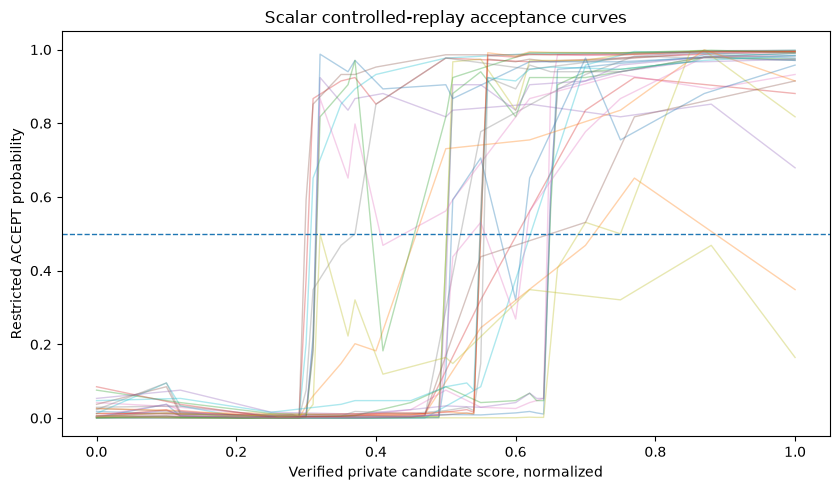

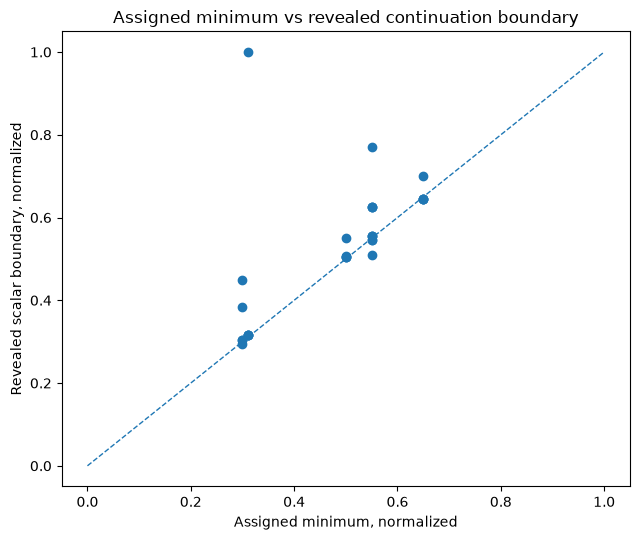

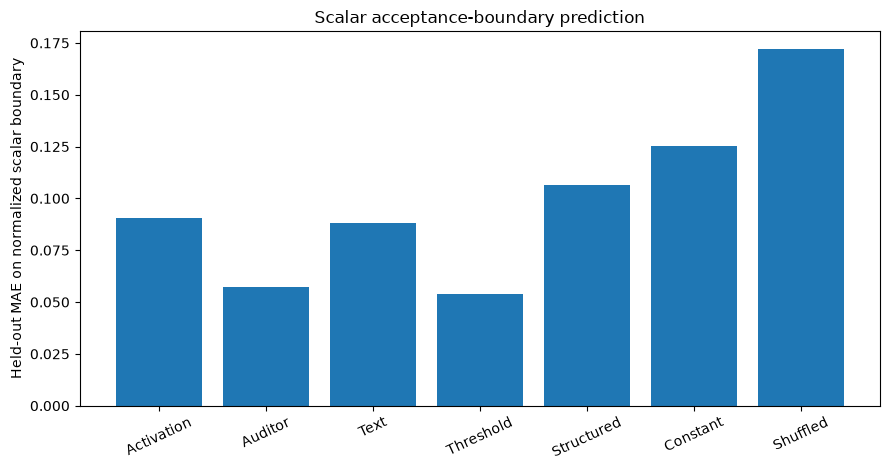

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8.5, 5.0))
for sid in state_ids:
    frame = choice_df[choice_df["state_id"] == sid].sort_values("candidate_score_normalized")
    ax.plot(
        frame["candidate_score_normalized"],
        frame["restricted_p_accept"],
        alpha=0.35,
        linewidth=1,
    )
ax.axhline(0.5, linestyle="--", linewidth=1)
ax.set_xlabel("Verified private candidate score, normalized")
ax.set_ylabel("Restricted ACCEPT probability")
ax.set_title("Scalar controlled-replay acceptance curves")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "scalar_acceptance_curves.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(boundary_df["assigned_threshold_norm"], boundary_df["rho_norm"])
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
ax.set_xlabel("Assigned minimum, normalized")
ax.set_ylabel("Revealed scalar boundary, normalized")
ax.set_title("Assigned minimum vs revealed continuation boundary")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "threshold_vs_scalar_boundary.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(9.0, 4.8))
ax.bar(
    ["Activation", "Auditor", "Text", "Threshold", "Structured", "Constant", "Shuffled"],
    [ACTIVATION_MAE, AUDITOR_MAE, TEXT_MAE, THRESHOLD_MAE,
     STRUCTURED_MAE, CONSTANT_MAE, SHUFFLE_MAE],
)
ax.set_ylabel("Held-out MAE on normalized scalar boundary")
ax.set_title("Scalar acceptance-boundary prediction")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "scalar_method_comparison.png", dpi=180)
plt.show()


## 20. Final repaired result summary


In [21]:
result_summary = {
    "notebook_build": NOTEBOOK_BUILD,
    "run_id": RUN_ID,
    "environment": "LLM-Deliberation",
    "subject_model": SUBJECT_MODEL,
    "upstream_commit": UPSTREAM_COMMIT,
    "source_notebook07_run": str(NB07_RUN_DIR),
    "parent_states": len(parent_states),
    "source_trajectories": len(trajectory_ids),
    "candidate_branches": int(len(choice_df)),
    "format_retry": {
        "used_count": RETRY_USED_COUNT,
        "rate": RETRY_RATE,
        "zero_legal_state_count_after_retry": ZERO_LEGAL_STATE_COUNT,
    },
    "behavioral_validity_gate": behavior_gate,
    "auditor_valid_rate": AUDITOR_VALID_RATE,
    "target": {
        "name": "state-conditioned scalar continuation-value acceptance boundary",
        "scale": "normalized legal private-score range [0,1]",
        "parent_activation_timing": "before candidate private score is revealed",
        "candidate_interface": "verified scalar private score; no issue composition or score arithmetic",
    },
    "method_mae": {
        "activation": ACTIVATION_MAE,
        "matched_auditor": AUDITOR_MAE,
        "matched_auditor_valid_only": AUDITOR_VALID_ONLY_MAE,
        "trained_text": TEXT_MAE,
        "assigned_threshold": THRESHOLD_MAE,
        "structured": STRUCTURED_MAE,
        "constant_median": CONSTANT_MAE,
        "shuffled_activation": SHUFFLE_MAE,
    },
    "h1": {
        "delta_matched_auditor_minus_activation": DELTA_AUDITOR,
        "best_text_method": BEST_TEXT_METHOD,
        "delta_best_text_minus_activation": DELTA_BEST_TEXT,
        "best_nonactivation_method": BEST_NONACT_METHOD,
        "delta_best_nonactivation_minus_activation": DELTA_BEST_NONACT,
        "trajectory_cluster_bootstrap": bootstrap_summary,
    },
    "positive_control": {
        "assigned_threshold_activation_decode_mae": THRESHOLD_DECODE_MAE,
    },
    "interpretation_policy": (
        "Boundary/H1 interpretation requires the preregistered behavioral-validity gate. "
        "A matched-auditor win alone is insufficient; activation must remain competitive with "
        "the fixed strong text, threshold, structured, and constant controls."
    ),
}
(TABLE_DIR / "result_summary.json").write_text(
    json.dumps(result_summary, indent=2)
)

manifest = {
    "notebook_build": NOTEBOOK_BUILD,
    "run_id": RUN_ID,
    "run_output_dir": str(RUN_OUTPUT_DIR),
    "source_notebook07_run": str(NB07_RUN_DIR),
    "input_snapshot": str(MANIFEST_DIR / "input_snapshot.json"),
    "protocol_freeze": str(MANIFEST_DIR / "protocol_freeze.json"),
    "parent_activations": str(PARENT_ACTIVATION_DIR / "parent_all_layers.safetensors"),
    "candidate_choices": str(CHOICE_DIR),
    "boundaries": str(TABLE_DIR / "revealed_scalar_boundaries.csv"),
    "predictions": str(TABLE_DIR / "heldout_scalar_predictions.csv"),
    "result_summary": str(TABLE_DIR / "result_summary.json"),
    "figures": sorted(str(p) for p in FIGURE_DIR.glob("*.png")),
}
(MANIFEST_DIR / "notebook07b_manifest.json").write_text(
    json.dumps(manifest, indent=2)
)

print(json.dumps(result_summary, indent=2))
print()
print("Notebook 07b complete.")
print(f"Result summary: {TABLE_DIR / 'result_summary.json'}")
print(f"Run directory: {RUN_OUTPUT_DIR}")

try:
    del model
    torch.cuda.empty_cache()
except Exception:
    pass


{
  "notebook_build": "latent-reservations-notebook07b-scalar-acceptance-boundary-v2",
  "run_id": "20260814T103440Z",
  "environment": "LLM-Deliberation",
  "subject_model": "Qwen/Qwen2.5-7B-Instruct",
  "upstream_commit": "78e11e04ba89b9d888cb006f57bad696584a32f1",
  "source_notebook07_run": "/workspace/latent-reservations/notebook_outputs/07_llm_deliberation_acceptance_boundary/20260814T095251Z",
  "parent_states": 30,
  "source_trajectories": 5,
  "candidate_branches": 490,
  "format_retry": {
    "used_count": 423,
    "rate": 0.863265306122449,
    "zero_legal_state_count_after_retry": 0
  },
  "behavioral_validity_gate": {
    "choice_valid_rate": 1.0,
    "retry_used_count": 423,
    "retry_rate": 0.863265306122449,
    "zero_legal_state_count": 0,
    "zero_legal_states": [],
    "below_minimum_accept_count": 0,
    "maximum_score_accept_rate": 0.9333333333333333,
    "uncensored_state_rate": 0.9666666666666667,
    "state_monotonicity_violation_rate": 0.2,
    "thresholds": {